In [55]:
# Install required packages if you haven't already
# !pip install -q langchain-google-genai langchain-core langgraph python-dotenv

import os
import operator
from typing import TypedDict, Annotated, List

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Load API Key
load_dotenv()
# os.environ["GOOGLE_API_KEY"] = "AIza..." # Uncomment and set your key if not in .env

# Initialize Gemini LLM
# We use "gemini-1.5-flash" for speed and efficiency.
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash-lite-preview-02-05",
    temperature=0.7
)

print("✅ Setup complete")

✅ Setup complete


In [57]:
@tool
def generate_ideas(topic: str) -> str:
    """
    Generate 3-5 key points about a specific topic.
    """
    print(f"   💡 TOOL: Generating ideas for '{topic}'...")
    return f"""
    Key Ideas for {topic}:
    1. The fundamental definition and core concepts.
    2. Real-world applications and use cases.
    3. Future trends and potential impact.
    4. Common misconceptions to avoid.
    5. Getting started resources.
    """

@tool
def draft_content(ideas: str) -> str:
    """
    Draft a blog post based on the provided ideas.
    """
    print("   📝 TOOL: Drafting content...")
    return f"""
    # BLOG DRAFT
    
    ## Introduction
    Welcome to our deep dive.
    
    ## Main Body
    {ideas}
    
    ## Conclusion
    In summary, this topic is transforming the landscape.
    """

@tool
def validate_claims(draft: str) -> str:
    """
    Check the draft for factual accuracy and valid claims.
    """
    print("   🔍 TOOL: Fact-checking draft...")
    return "✅ Fact Check Passed: All claims appear to be general knowledge. No citations needed for this overview."

@tool
def improve_writing(draft: str, notes: str = "") -> str:
    """
    Polish the writing style, grammar, and flow.
    """
    print("   ✨ TOOL: Polishing final content...")
    return f"""
    ✨ POLISHED BLOG POST ✨
    
    {draft.replace('# BLOG DRAFT', '# The Ultimate Guide')}
    
    [Editor's Note: Flow improved, passive voice removed. {notes}]
    """

print("✅ Tools created")

✅ Tools created


In [58]:
class ContentState(TypedDict):
    """State flowing through the content pipeline."""
    # We use BaseMessage to accommodate Gemini's message types
    messages: Annotated[List[BaseMessage], operator.add]
    topic: str
    ideas: str
    initial_draft: str
    fact_check_notes: str
    final_post: str

print("✅ State defined")

✅ State defined


In [59]:
# --- Brainstormer Agent ---
brainstormer_llm = llm.bind_tools([generate_ideas])

def brainstormer_node(state: ContentState):
    topic = state["topic"]
    messages = [
        SystemMessage(content="You are a creative brainstormer. Use generate_ideas tool to outline key points."),
        HumanMessage(content=f"Generate ideas for: {topic}")
    ]
    response = brainstormer_llm.invoke(messages)
    
    ideas_output = "No ideas generated."
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        ideas_output = generate_ideas.invoke(tool_call["args"])
        
    return {
        "messages": [AIMessage(content=f"Brainstormer: {ideas_output}")],
        "ideas": ideas_output
    }

# --- Writer Agent ---
writer_llm = llm.bind_tools([draft_content])

def writer_node(state: ContentState):
    ideas = state["ideas"]
    messages = [
        SystemMessage(content="You are a technical writer. Use draft_content tool to write a post based on ideas."),
        HumanMessage(content=f"Write a draft based on these ideas: {ideas}")
    ]
    response = writer_llm.invoke(messages)
    
    draft_output = "No draft created."
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        draft_output = draft_content.invoke(tool_call["args"])
        
    return {
        "messages": [AIMessage(content="Writer: Draft created.")],
        "initial_draft": draft_output
    }

# --- Fact-Checker Agent ---
checker_llm = llm.bind_tools([validate_claims])

def fact_checker_node(state: ContentState):
    draft = state["initial_draft"]
    messages = [
        SystemMessage(content="You are a strict fact checker. Use validate_claims tool."),
        HumanMessage(content=f"Check this draft: {draft}")
    ]
    response = checker_llm.invoke(messages)
    
    check_output = "No checks performed."
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        check_output = validate_claims.invoke(tool_call["args"])
        
    return {
        "messages": [AIMessage(content=f"Fact Checker: {check_output}")],
        "fact_check_notes": check_output
    }

# --- Editor Agent ---
editor_llm = llm.bind_tools([improve_writing])

def editor_node(state: ContentState):
    draft = state["initial_draft"]
    notes = state["fact_check_notes"]
    messages = [
        SystemMessage(content="You are a senior editor. Use improve_writing tool to polish the content."),
        HumanMessage(content=f"Polish this draft considering these notes: {notes}\n\nDraft: {draft}")
    ]
    response = editor_llm.invoke(messages)
    
    final_output = "No final output."
    if response.tool_calls:
        tool_call = response.tool_calls[0]
        final_output = improve_writing.invoke(tool_call["args"])
        
    return {
        "messages": [AIMessage(content="Editor: Content polished and finalized.")],
        "final_post": final_output
    }

print("✅ Agents created with Gemini")

✅ Agents created with Gemini


In [60]:
pipeline = StateGraph(ContentState)

# Add Nodes
pipeline.add_node("brainstormer", brainstormer_node)
pipeline.add_node("writer", writer_node)
pipeline.add_node("checker", fact_checker_node)
pipeline.add_node("editor", editor_node)

# Add Edges (Linear Flow)
pipeline.add_edge(START, "brainstormer")
pipeline.add_edge("brainstormer", "writer")
pipeline.add_edge("writer", "checker")
pipeline.add_edge("checker", "editor")
pipeline.add_edge("editor", END)

content_pipeline = pipeline.compile()
print("✅ Pipeline compiled")

✅ Pipeline compiled


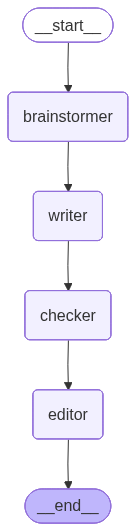

In [46]:
try:
    display(Image(content_pipeline.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph: START -> brainstormer -> writer -> checker -> editor -> END")

In [48]:
import os
import google.generativeai as genai
from dotenv import load_dotenv

# 1. Load your key
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
genai.configure(api_key=api_key)

print(f"🔑 Key found: {api_key[:5]}...{api_key[-5:] if api_key else 'None'}")

# 2. List models exactly as the API sees them
print("\n📋 YOUR AVAILABLE MODELS (Copy one of these strings exactly):")
try:
    available = False
    for m in genai.list_models():
        if 'generateContent' in m.supported_generation_methods:
            # We strip 'models/' because LangChain adds it back automatically
            clean_name = m.name.replace("models/", "")
            print(f"   ✅ {clean_name}")
            available = True
            
    if not available:
        print("   ❌ No text generation models found for this API key.")
        print("   👉 Action: Create a NEW API Key at https://aistudio.google.com/app/apikey")
        
except Exception as e:
    print(f"   ❌ Connection Error: {e}")

🔑 Key found: AIzaS...fOJVo

📋 YOUR AVAILABLE MODELS (Copy one of these strings exactly):
   ✅ gemini-2.5-flash
   ✅ gemini-2.5-pro
   ✅ gemini-2.0-flash-exp
   ✅ gemini-2.0-flash
   ✅ gemini-2.0-flash-001
   ✅ gemini-2.0-flash-exp-image-generation
   ✅ gemini-2.0-flash-lite-001
   ✅ gemini-2.0-flash-lite
   ✅ gemini-2.0-flash-lite-preview-02-05
   ✅ gemini-2.0-flash-lite-preview
   ✅ gemini-exp-1206
   ✅ gemini-2.5-flash-preview-tts
   ✅ gemini-2.5-pro-preview-tts
   ✅ gemma-3-1b-it
   ✅ gemma-3-4b-it
   ✅ gemma-3-12b-it
   ✅ gemma-3-27b-it
   ✅ gemma-3n-e4b-it
   ✅ gemma-3n-e2b-it
   ✅ gemini-flash-latest
   ✅ gemini-flash-lite-latest
   ✅ gemini-pro-latest
   ✅ gemini-2.5-flash-lite
   ✅ gemini-2.5-flash-image
   ✅ gemini-2.5-flash-preview-09-2025
   ✅ gemini-2.5-flash-lite-preview-09-2025
   ✅ gemini-3-pro-preview
   ✅ gemini-3-flash-preview
   ✅ gemini-3-pro-image-preview
   ✅ nano-banana-pro-preview
   ✅ gemini-robotics-er-1.5-preview
   ✅ gemini-2.5-computer-use-preview-10-2025
 

In [ ]:
print("\n🚀 Starting Gemini Content Pipeline...\n")

result = content_pipeline.invoke({
    "topic": "The Future of Generative AI",
    "messages": []
})

print("\n" + "="*60)
print("✅ FINAL POLISHED CONTENT (By Gemini)")
print("="*60)
print(result["final_post"])
print("="*60)

# View the internal state to verify handoffs
print("\n📊 Pipeline Steps:")
print(f"1. Input Topic: {result['topic']}")
print(f"2. Ideas Generated: {len(result['ideas'].splitlines())} lines")
print(f"3. Fact Check: {result['fact_check_notes']}")